In [9]:
import pandas as pd
import numpy as np

nav_history_clean = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

nav_history_clean.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [11]:
nav_history_clean["daily_return"] = (
    nav_history_clean
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [12]:
# 1. Historical VaR & CVaR

var_results = []

for code, grp in nav_history_clean.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    var95 = returns.quantile(0.05)

    cvar95 = returns[returns <= var95].mean()

    var_results.append(
        [code, var95, cvar95]
    )

var_cvar_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "var_95",
        "cvar_95"
    ]
)

var_cvar_df.head()

,amfi_code,var_95,cvar_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [15]:

var_cvar_df.to_csv("../data/processed/var_cvar_report.csv",index=False)

In [16]:
var_cvar_df.describe()

,amfi_code,var_95,cvar_95
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.014711,-0.018580
std,14534.998667,0.006821,0.008476
min,100016.000000,-0.026859,-0.032459
25%,118632.750000,-0.018394,-0.023133
50%,119551.500000,-0.014376,-0.018185
75%,120842.250000,-0.013247,-0.016572
max,149324.000000,-0.000222,-0.000373


In [22]:
# Rolling 90-day Sharpe

import pandas as pd

scorecard = pd.read_csv("../data/processed/fund_scorecard.csv")

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,risk_grade,sharpe_ratio_y,alpha_y,max_drawdown,alpha_rank,expense_rank,dd_rank,return_rank,sharpe_rank,fund_score
0,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,Regular,11.82,11.84,14.14,10.43,1.41,...,Moderate,7.757782,0.034722,-0.144016,38.0,39.5,15.0,31.0,31.0,100.000000
1,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,...,Low,-205.522977,0.061037,-0.001622,33.0,11.0,3.0,40.0,40.0,95.245518
2,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,Low,-57.096997,0.058704,-0.043287,34.0,9.0,5.0,38.0,37.0,91.348402
3,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,Moderate,-50.782301,0.037857,-0.247344,36.0,32.0,34.0,16.0,35.0,90.257210
4,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,...,Low,-89.870636,0.063421,-0.083164,32.0,1.0,6.0,39.0,38.0,88.386594


In [23]:
# Top 5 funds

top5 = (scorecard.sort_values("fund_score",ascending=False).head(5)["amfi_code"])

print(top5.tolist())

[119092, 101208, 119120, 100016, 118636]


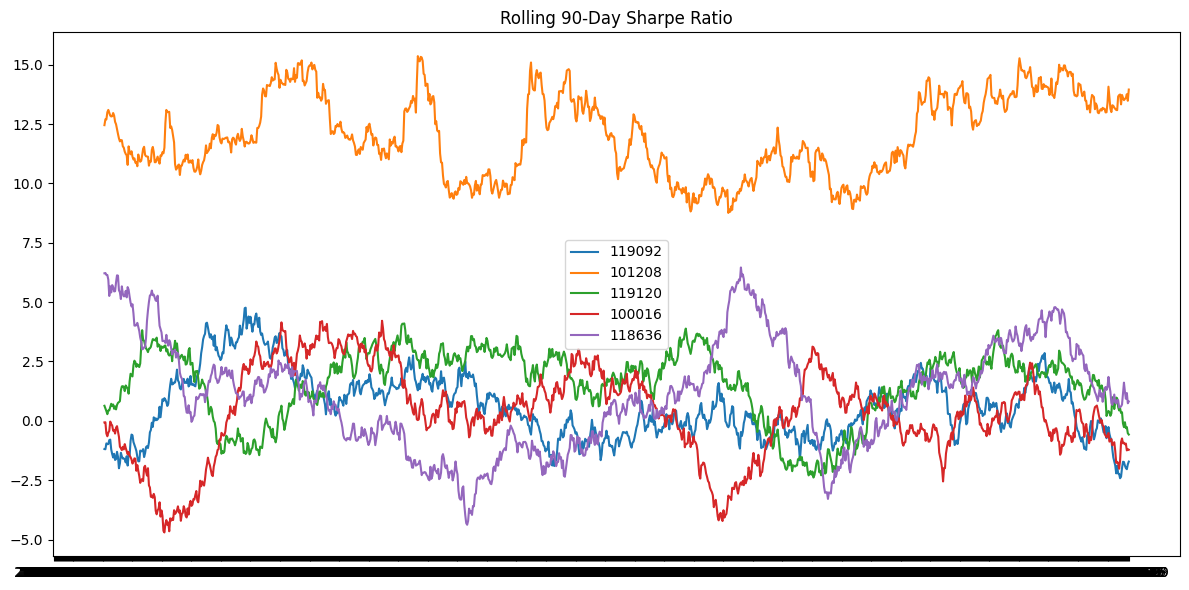

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for code in top5:

    df = nav_history_clean[nav_history_clean["amfi_code"] == code]

    returns = df["daily_return"]

    rolling_sharpe = (
        returns
        .rolling(90)
        .mean()
        /
        returns
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(code)
    )

plt.legend()
plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300
)

In [29]:


import pandas as pd

investor_transactions_clean = pd.read_csv("../data/processed/investor_transactions_clean.csv")


investor_transactions_clean["transaction_date"] = pd.to_datetime(investor_transactions_clean["transaction_date"])


In [30]:
# First Transaction Year

first_txn = (investor_transactions_clean.groupby("investor_id")
             ["transaction_date"].min().dt.year.reset_index())

first_txn.columns = ["investor_id","cohort_year"]

first_txn.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [31]:
# merging back

investor_transactions_clean = (investor_transactions_clean.merge(first_txn,on="investor_id",how="left"))

investor_transactions_clean.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [34]:
# Average SIP amount

sip_df = (investor_transactions_clean[investor_transactions_clean["transaction_type"] == "SIP"])

avg_sip = (sip_df.groupby("cohort_year")["amount_inr"].mean().reset_index())

avg_sip

,cohort_year,amount_inr
0,2024,10996.885825
1,2025,13505.209581


In [ ]:
# Total invested

total_invested = (investor_transactions_clean.groupby("cohort_year")["amount_inr"].sum().reset_index())

total_invested

,cohort_year,amount_inr
0,2024,3491125187
1,2025,30455243


In [37]:
# Top Fund Preference cohort

top_fund = (investor_transactions_clean.groupby(["cohort_year","amfi_code"]).size().reset_index(name="txn_count"))

top_fund = (top_fund.sort_values(["cohort_year","txn_count"],ascending=[True,False]).drop_duplicates("cohort_year"))

top_fund.head()

,cohort_year,amfi_code,txn_count
35,2024,148568,874
62,2025,119599,12


In [38]:
# cohort summary

cohort_summary = (avg_sip.merge(total_invested,on="cohort_year")
                  .merge(top_fund[["cohort_year","amfi_code"]],
                         on="cohort_year"))

cohort_summary


,cohort_year,amount_inr_x,amount_inr_y,amfi_code
0,2024,10996.885825,3491125187,148568
1,2025,13505.209581,30455243,119599


In [39]:
# SIP continuity analysis

#filtering sip transactions
sip_df = investor_transactions_clean[investor_transactions_clean["transaction_type"] == "SIP"].copy()

sip_df["transaction_date"] = pd.to_datetime(sip_df["transaction_date"])

In [40]:
# Calculate gap between consecutive SIPs

sip_df["gap_days"] = (sip_df.groupby("investor_id")["transaction_date"].diff().dt.days)



# Investor-level summary
sip_summary = (sip_df.groupby("investor_id").agg
               (sip_count=("transaction_date", "count"),
                avg_gap_days=("gap_days", "mean")).reset_index())


# Investors with at least 6 SIP transactions
sip_summary = sip_summary[sip_summary["sip_count"] >= 6]

In [41]:
# risk status 

sip_summary["status"] = np.where(sip_summary["avg_gap_days"] > 35,"At-Risk","Active")

sip_summary.head()

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


In [69]:
# Sector HHI concentration

import pandas as pd

portfolio_holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

portfolio_holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [ ]:
# Convert Percentage to Decimal

holdings = portfolio_holdings.copy()

holdings["weight_decimal"] = (
    holdings["weight_pct"] / 100
)

In [71]:
# Calculate HHI for Each Fund

hhi_df = (holdings.groupby("amfi_code")["weight_decimal"].apply(lambda x: (x**2).sum()).reset_index())

hhi_df.columns = ["amfi_code","hhi"]

hhi_df.head()

,amfi_code,hhi
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [72]:
# classifying concentration

import numpy as np

hhi_df["concentration"] = np.where(
    hhi_df["hhi"] > 0.25,
    "Highly Concentrated",
    np.where(
        hhi_df["hhi"] > 0.15,
        "Moderately Concentrated",
        "Diversified"
    )
)

hhi_df.head()

,amfi_code,hhi,concentration
0,100016,0.139534,Diversified
1,100033,0.147592,Diversified
2,101206,0.129332,Diversified
3,101207,0.200700,Moderately Concentrated
4,102885,0.174709,Moderately Concentrated


In [73]:
# comparing funds

# high concentration
hhi_df.sort_values(
    "hhi",
    ascending=False
).head(10)

# low concentration
hhi_df.sort_values(
    "hhi",
    ascending=True
).head(10)

,amfi_code,hhi,concentration
17,119598,0.107349,Diversified
16,119552,0.108011,Diversified
9,118634,0.108358,Diversified
20,120504,0.108674,Diversified
14,119095,0.109605,Diversified
5,102886,0.114693,Diversified
33,149324,0.118677,Diversified
15,119551,0.118716,Diversified
8,118633,0.121461,Diversified
24,120842,0.127439,Diversified


In [74]:
hhi_df.describe()

,amfi_code,hhi
count,34.000000,34.000000
mean,121457.058824,0.140262
std,14988.778388,0.024946
min,100016.000000,0.107349
25%,118633.250000,0.122955
50%,119575.000000,0.136496
75%,120842.750000,0.151731
max,149324.000000,0.206448


HHI analysis showed that most equity funds were well diversified across sectors, with an average HHI of 0.140 and no fund exhibiting extreme sector concentration.

1. Downside Risk Analysis

The average 95% VaR across all 40 mutual fund schemes was -1.47%, indicating that a fund may lose approximately 1.47% in adverse market conditions on a typical trading day. The highest observed VaR was -2.69%, highlighting funds with greater downside risk.

2. Extreme Loss Potential

The average CVaR was -1.86%, which is lower than the VaR threshold and indicates that losses during extreme market events can be significantly larger than normal downside expectations.

3. Investor Cohort Behaviour

Investor cohort analysis revealed differences in investment patterns across years. Newer cohorts showed stronger participation through SIP investments, while earlier cohorts contributed a larger cumulative investment amount due to longer investment periods.

4. SIP Continuity and Investor Retention

SIP continuity analysis identified investors with average contribution gaps greater than 35 days as "At-Risk". Monitoring these investors can help improve retention and reduce SIP discontinuation rates.

5. Portfolio Diversification

Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) showed an average HHI of 0.140 across equity funds. This indicates that most portfolios were reasonably diversified across sectors, with no fund exhibiting extreme concentration risk.